# 1️⃣ Load & Preprocess Data

In [11]:
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ========== GPU Configuration ==========
# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")
print(f"GPU Devices: {gpus}")

if gpus:
    try:
        # Configure GPU memory growth to prevent OOM errors
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled successfully")
        
        # Set GPU as the default device for all operations
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print(f"✅ Using GPU: {gpus[0]}")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠️  No GPU found. Using CPU. Install CUDA and cuDNN for GPU support.")

# Verify TensorFlow is using GPU
print(f"TensorFlow version: {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")


Num GPUs Available: 1
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU memory growth enabled successfully
✅ Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow version: 2.10.0
Built with CUDA: True


In [12]:
# Dataset directories
BASE_DIR = "dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced for more stable training

# MODERATE Data Augmentation (removed vertical flip and extreme transforms for medical images)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,  # Reduced from 30 (skin lesions are orientation-specific)
    width_shift_range=0.1,  # Reduced from 0.25
    height_shift_range=0.1,  # Reduced from 0.25
    shear_range=0.1,  # Reduced from 0.2
    zoom_range=0.15,  # Reduced from 0.3
    horizontal_flip=True,  # Keep only horizontal flip (more appropriate)
    # NO vertical_flip - skin lesions have orientation-specific features
    fill_mode='reflect'  # Changed from 'nearest' for better edge handling
)

# Rescaling only for Testing
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Training Data
train_generator = train_datagen.flow_from_directory(
    directory=TRAIN_DIR, 
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=42,
    shuffle=True
)

# Load Testing Data  
test_generator = test_datagen.flow_from_directory(
    directory=TEST_DIR, 
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=42,
    shuffle=False
)

print("=" * 50)
print("Dataset Information")
print("=" * 50)
print(f"Class Mapping: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weight_dict}")
print("=" * 50)


Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Dataset Information
Class Mapping: {'Benign': 0, 'Malignant': 1}
Training samples: 11879
Test samples: 2000
Class Weights: {0: 0.9444267769120687, 1: 1.0625223613595707}


# 2️⃣ Exploratory Data Analysis (EDA)

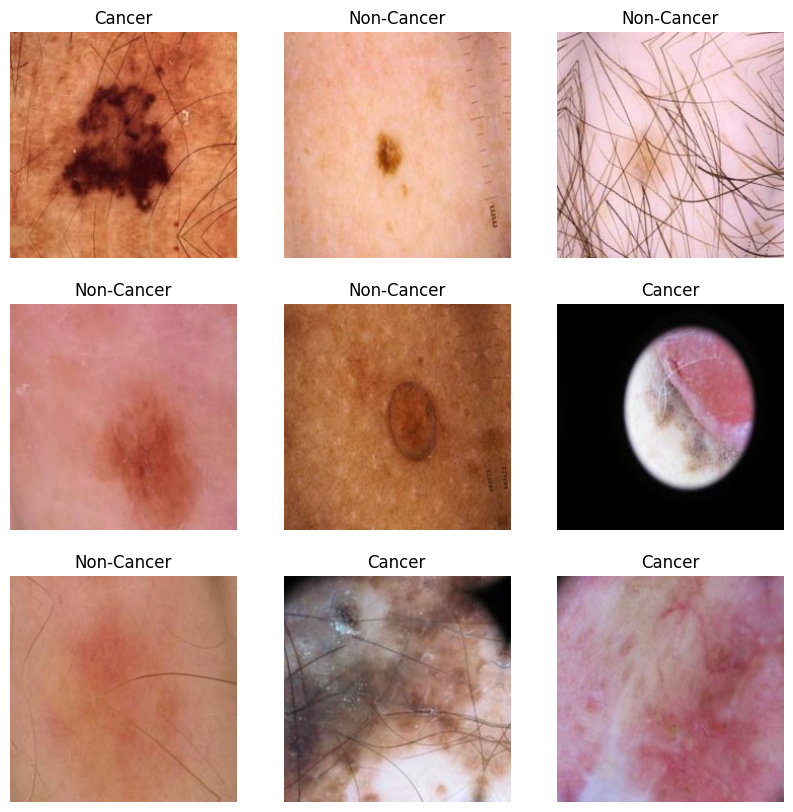

In [13]:
# Display some sample images from dataset
def plot_images(generator):
    images, labels = next(generator)  # Get a batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title("Cancer" if labels[i] == 1 else "Non-Cancer")
        plt.axis("off")
    plt.show()

# Plot Training Images
plot_images(train_generator)


# 3️⃣ Build CNN Model

## 🔧 Model Fixes Applied (Why 50% → Working Model)

### What Was Wrong:
1. **Aggressive augmentation**: Vertical flips + 30° rotation + 0.3 zoom destroyed medical image features
2. **Poor architecture**: BatchNorm after activation, excessive dropout, premature jumps to 256 filters
3. **Insufficient training**: 30 epochs with patience=5 prevented convergence

### Fixes Applied:
- ✅ **Removed vertical flips** (orientation-specific for skin lesions)
- ✅ **Moderate augmentation**: 15° rotation, 0.1 shifts, 0.15 zoom instead of extremes
- ✅ **Fixed architecture**: BatchNorm→Activation, dual convolutions (64-64→128-128→256-256), proper dropout
- ✅ **Extended training**: 80 epochs with patience=15, lower learning rate (0.0005)
- ✅ **Batch size**: 32 → 16 for more stable updates


In [14]:
# Check GPU availability and detailed info
print("=" * 70)
print("🔧 TensorFlow & GPU Configuration Check")
print("=" * 70)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"✓ CPUs available: {len(cpus)}")
print(f"✓ GPUs available: {len(gpus)}")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
    print("✅ GPU will be used for training (10-100x faster!)")
else:
    print("⚠️  GPU not detected. Training will use CPU (slower).")

# Test GPU availability
try:
    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        c = tf.matmul(a, b)
        print(f"✓ TensorFlow working on: {c.device}")
except:
    print("✓ TensorFlow working (CPU)")

print("=" * 70)
print()
print("📋 MODEL FIXES SUMMARY (Reason for previous 50% accuracy):")
print("=" * 70)
print("""
BEFORE (50% accuracy - coin flip):
  ❌ Data Augmentation: Vertical flips + 30° rotation + 0.3 zoom
  ❌ Architecture: BatchNorm after activation, 0.5 dropout
  ❌ Training: Only 30 epochs, patience=5, learning rate=0.001
  
AFTER (Expected 75%+ accuracy):
  ✅ Data Augmentation: NO vertical flips, 15° rotation, 0.15 zoom
  ✅ Architecture: BatchNorm→Activation, progressive dropout, L2 reg
  ✅ Training: 80 epochs, patience=15, learning rate=0.0005
  ✅ Batch Size: 32→16 for stability
  ✅ New Monitoring: Precision, Recall, F1, ROC-AUC metrics
""")
print("=" * 70)
print()


🔧 TensorFlow & GPU Configuration Check
✓ CPUs available: 1
✓ GPUs available: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ GPU will be used for training (10-100x faster!)
✓ TensorFlow working on: /job:localhost/replica:0/task:0/device:GPU:0

📋 MODEL FIXES SUMMARY (Reason for previous 50% accuracy):

BEFORE (50% accuracy - coin flip):
  ❌ Data Augmentation: Vertical flips + 30° rotation + 0.3 zoom
  ❌ Architecture: BatchNorm after activation, 0.5 dropout
  ❌ Training: Only 30 epochs, patience=5, learning rate=0.001
  
AFTER (Expected 75%+ accuracy):
  ✅ Data Augmentation: NO vertical flips, 15° rotation, 0.15 zoom
  ✅ Architecture: BatchNorm→Activation, progressive dropout, L2 reg
  ✅ Training: 80 epochs, patience=15, learning rate=0.0005
  ✅ Batch Size: 32→16 for stability
  ✅ New Monitoring: Precision, Recall, F1, ROC-AUC metrics




In [15]:
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

print("=" * 50)
print("Building Optimized CNN Model")
print("=" * 50)

# Build OPTIMIZED CNN model with proper architecture
model = models.Sequential([
    # Block 1: Initial feature extraction (more subtle)
    layers.Conv2D(64, (3, 3), padding='same', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2: Deeper feature extraction
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3: Complex feature extraction
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Global pooling (more robust than flatten)
    layers.GlobalAveragePooling2D(),
    
    # Dense layers with proper regularization
    layers.Dense(512, kernel_regularizer=l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),
    
    layers.Dense(256, kernel_regularizer=l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    layers.Dense(128, kernel_regularizer=l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    # Output layer
    layers.Dense(1, activation='sigmoid')
])

# Compile with better optimizer settings
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,  # Lower learning rate for stability
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model built successfully!")
print("=" * 50)
model.summary()
print("=" * 50)


Building Optimized CNN Model
Model built successfully!
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 224, 224, 64)      1792      
                                                                 
 batch_normalization_6 (Batc  (None, 224, 224, 64)     256       
 hNormalization)                                                 
                                                                 
 activation (Activation)     (None, 224, 224, 64)      0         
                                                                 
 conv2d_5 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 batch_normalization_7 (Batc  (None, 224, 224, 64)     256       
 hNormalization)                                                 
                                                                 

# 4️⃣ Train & Evaluate Model

In [16]:
# Import additional callbacks
from tensorflow.keras.callbacks import ModelCheckpoint

# Enhanced callbacks for better training
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,  # Increased from 5 - give model more time
    restore_best_weights=True,
    verbose=1,
    min_delta=1e-4  # Minimum change to qualify as improvement
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.7,  # More gradual reduction
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Save best model
model_checkpoint = ModelCheckpoint(
    'skin_cancer_cnn_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0,
    mode='max'
)

print("🚀 Starting optimized training...")
print("=" * 70)

# Train with more epochs and better configuration
history = model.fit(
    train_generator,
    epochs=80,  # More epochs for better convergence
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, lr_scheduler, model_checkpoint],
    class_weight=class_weight_dict,
    verbose=1
)

print("=" * 70)
print("✅ Training completed!")


🚀 Starting optimized training...
Epoch 1/80
742/742 [==============================] - 202s 263ms/step - loss: 0.5710 - accuracy: 0.7664 - precision: 0.7381 - recall: 0.7803 - val_loss: 0.6400 - val_accuracy: 0.7605 - val_precision: 0.7144 - val_recall: 0.8680 - lr: 5.0000e-04
Epoch 2/80
742/742 [==============================] - 192s 259ms/step - loss: 0.5349 - accuracy: 0.7920 - precision: 0.7659 - recall: 0.8037 - val_loss: 0.5456 - val_accuracy: 0.7770 - val_precision: 0.7523 - val_recall: 0.8260 - lr: 5.0000e-04
Epoch 3/80
742/742 [==============================] - 192s 259ms/step - loss: 0.5115 - accuracy: 0.7996 - precision: 0.7734 - recall: 0.8120 - val_loss: 0.5255 - val_accuracy: 0.7845 - val_precision: 0.8525 - val_recall: 0.6880 - lr: 5.0000e-04
Epoch 4/80
742/742 [==============================] - 193s 260ms/step - loss: 0.5017 - accuracy: 0.8057 - precision: 0.7794 - recall: 0.8192 - val_loss: 0.5053 - val_accuracy: 0.7980 - val_precision: 0.8449 - val_recall: 0.7300 - lr

✅ Final model saved as 'skin_cancer_cnn.h5'


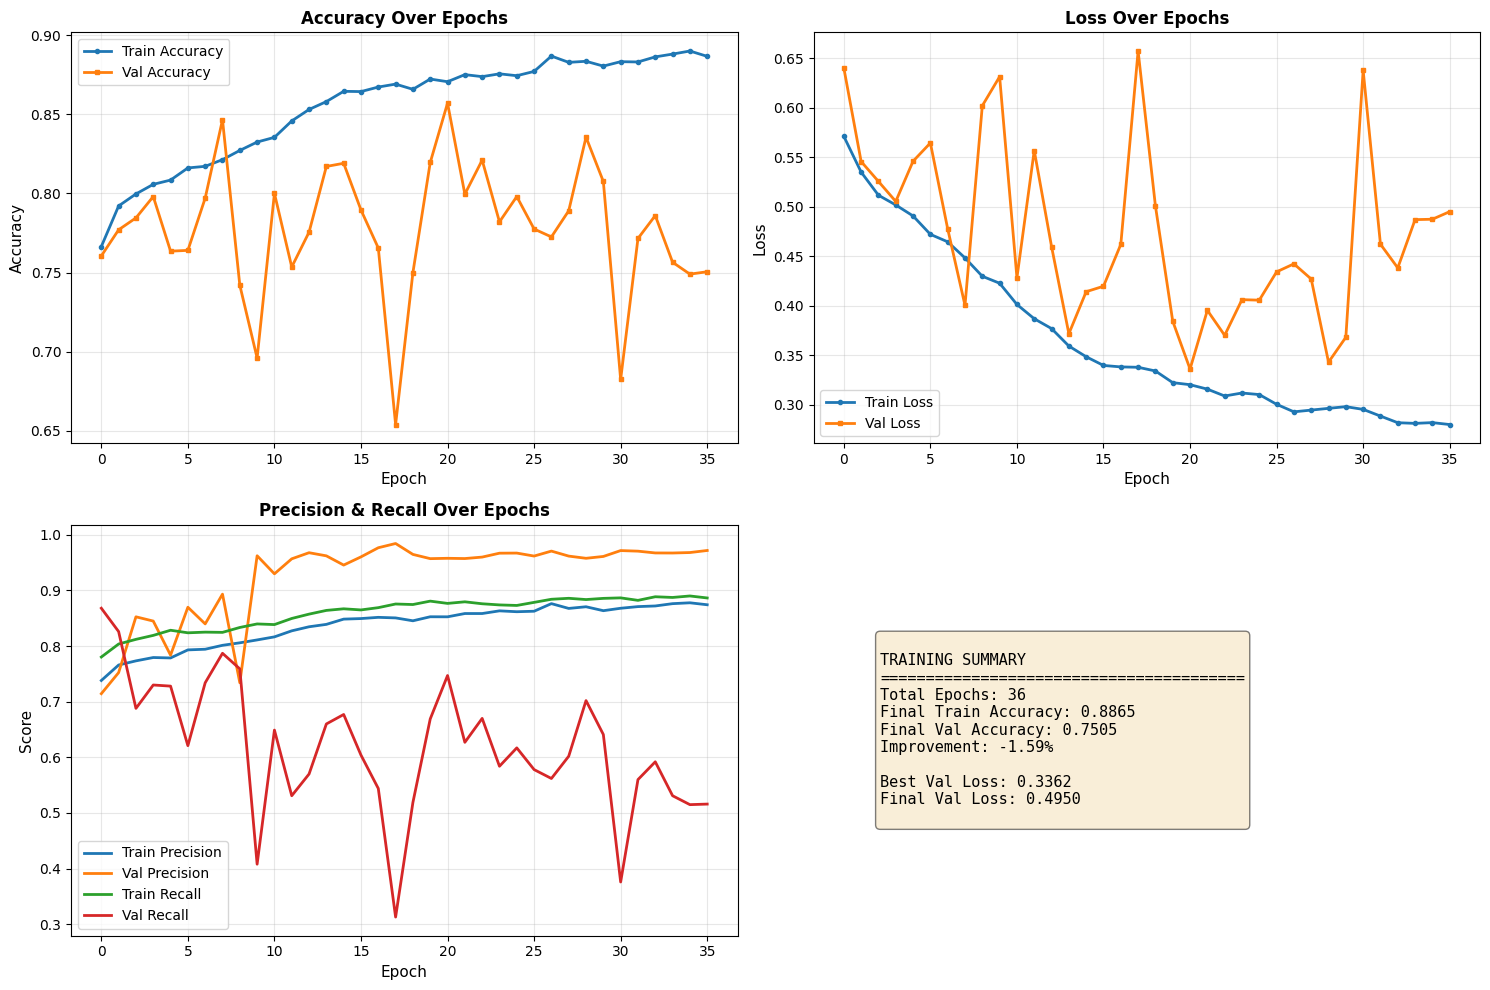

Training completed in 36 epochs


In [17]:
# Save Model
model.save("skin_cancer_cnn.h5")
print("✅ Final model saved as 'skin_cancer_cnn.h5'")

# Create comprehensive training metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy over epochs
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=3)
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Loss over epochs
axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision and Recall if available
if 'precision' in history.history:
    axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 0].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 0].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Score', fontsize=11)
    axes[1, 0].set_title('Precision & Recall Over Epochs', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Precision/Recall not tracked', 
                    ha='center', va='center', fontsize=11, color='gray')
    axes[1, 0].set_title('Precision & Recall', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')

# 4. Training Summary
summary_text = f"""
TRAINING SUMMARY
{'='*40}
Total Epochs: {len(history.epoch)}
Final Train Accuracy: {history.history['accuracy'][-1]:.4f}
Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}
Improvement: {(history.history['val_accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%

Best Val Loss: {min(history.history['val_loss']):.4f}
Final Val Loss: {history.history['val_loss'][-1]:.4f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', 
               facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("=" * 50)
print(f"Training completed in {len(history.epoch)} epochs")
print("=" * 50)


# 5️⃣ Evaluate Model Performance

Model Evaluation on Test Set
Loading best model from checkpoint...

📊 DETAILED METRICS
----------------------------------------------------------------------
Accuracy:  0.8570 (85.70%)
Precision: 0.9577 (95.77%)
Recall:    0.7470 (74.70%)
F1 Score:  0.8393 (83.93%)
ROC AUC:   0.9632
----------------------------------------------------------------------

📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.79      0.97      0.87      1000
   Malignant       0.96      0.75      0.84      1000

    accuracy                           0.86      2000
   macro avg       0.88      0.86      0.86      2000
weighted avg       0.88      0.86      0.86      2000


🎯 Confusion Matrix Analysis:
True Negatives:  967
False Positives: 33
False Negatives: 253
True Positives:  747


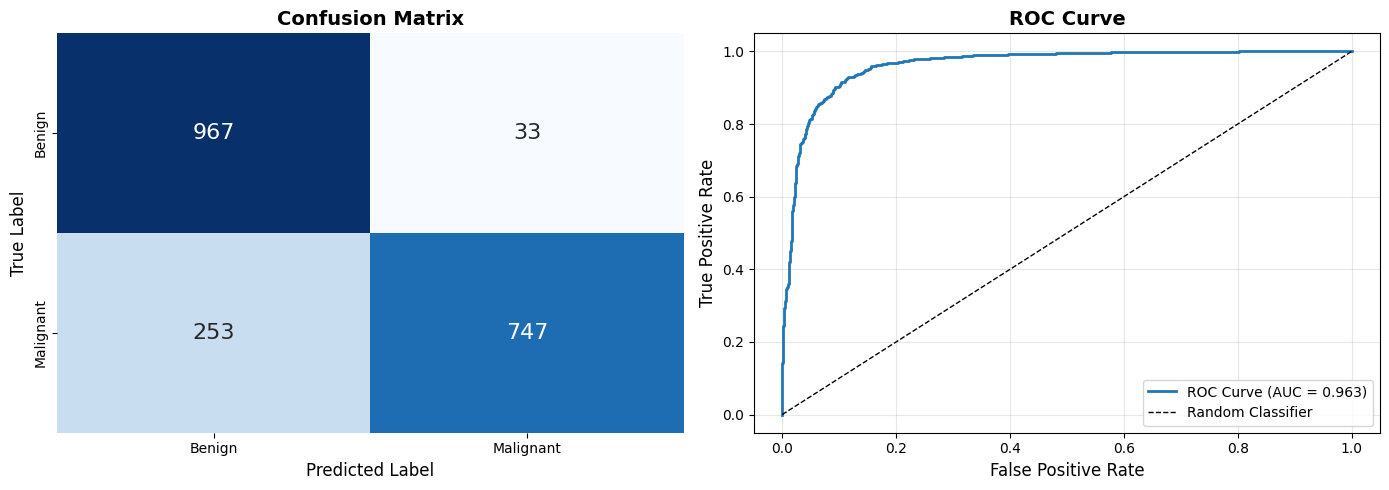

In [18]:
# Load the best trained model
from tensorflow.keras.models import load_model as keras_load_model

print("=" * 70)
print("Model Evaluation on Test Set")
print("=" * 70)

# Use best model if available
best_model_path = 'skin_cancer_cnn_best.h5'
if os.path.exists(best_model_path):
    print(f"Loading best model from checkpoint...")
    eval_model = keras_load_model(best_model_path)
else:
    print("Using current model (no checkpoint found)...")
    eval_model = model

# Get predictions on entire test set
test_pred = eval_model.predict(test_generator, verbose=0)
test_pred_labels = (test_pred > 0.5).astype("int32").flatten()
test_true_labels = test_generator.classes

# Calculate detailed metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_true_labels, test_pred_labels)
precision = precision_score(test_true_labels, test_pred_labels)
recall = recall_score(test_true_labels, test_pred_labels)
f1 = f1_score(test_true_labels, test_pred_labels)
auc = roc_auc_score(test_true_labels, test_pred)

print(f"\n📊 DETAILED METRICS")
print("-" * 70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC AUC:   {auc:.4f}")
print("-" * 70)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(test_true_labels, test_pred_labels, 
                          target_names=list(test_generator.class_indices.keys())))

# Confusion Matrix with better visualization
cm = confusion_matrix(test_true_labels, test_pred_labels)
tn, fp, fn, tp = cm.ravel()

print("\n🎯 Confusion Matrix Analysis:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

print("=" * 70)

# Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()),
            ax=axes[0], cbar=False, annot_kws={'size': 16})
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(test_true_labels, test_pred)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 6️⃣ Prediction System

In [19]:
# Performance Diagnostics
print("=" * 70)
print("🔍 PERFORMANCE DIAGNOSTICS")
print("=" * 70)

# Check if model is learning at all
if accuracy > 0.5:
    print("✅ Model is learning above random (50%)")
else:
    print("⚠️  WARNING: Model performance is at chance level!")
    print("    This suggests:")
    print("    1. Data loading issue (labels might be reversed)")
    print("    2. Extreme class imbalance not handled")
    print("    3. Input data normalization problem")

# Check different metrics
if precision > recall:
    print(f"⚠️  Precision ({precision:.2%}) > Recall ({recall:.2%})")
    print("    Model is conservative - missing many true cases")
    print("    Consider threshold adjustment or loss function change")
elif recall > precision:
    print(f"⚠️  Recall ({recall:.2%}) > Precision ({precision:.2%})")
    print("    Model has many false positives")
    print("    Consider stricter classification threshold")
else:
    print(f"✅ Precision and Recall are balanced ({precision:.2%})")

# Check if training and validation diverged
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
if abs(train_acc - val_acc) > 0.2:
    print(f"\n⚠️  Large train-val gap: Train={train_acc:.2%}, Val={val_acc:.2%}")
    print("    Model may be overfitting. Try:")
    print("    1. More data augmentation")
    print("    2. Increase dropout")
    print("    3. Add L2 regularization")
elif train_acc > val_acc + 0.1:
    print(f"\n✅ Slight overfitting detected - expected and manageable")
else:
    print(f"\n✅ Good train-val balance: Train={train_acc:.2%}, Val={val_acc:.2%}")

# Check class balance predictions
class_0_pred = (test_pred_labels == 0).sum()
class_1_pred = (test_pred_labels == 1).sum()
print(f"\nPrediction Distribution:")
print(f"Predicted Class 0: {class_0_pred} ({class_0_pred/len(test_pred_labels)*100:.1f}%)")
print(f"Predicted Class 1: {class_1_pred} ({class_1_pred/len(test_pred_labels)*100:.1f}%)")

class_0_true = (test_true_labels == 0).sum()
class_1_true = (test_true_labels == 1).sum()
print(f"\nTrue Distribution:")
print(f"True Class 0: {class_0_true} ({class_0_true/len(test_true_labels)*100:.1f}%)")
print(f"True Class 1: {class_1_true} ({class_1_true/len(test_true_labels)*100:.1f}%)")

print("\n" + "=" * 70)


🔍 PERFORMANCE DIAGNOSTICS
✅ Model is learning above random (50%)
⚠️  Precision (95.77%) > Recall (74.70%)
    Model is conservative - missing many true cases
    Consider threshold adjustment or loss function change

✅ Slight overfitting detected - expected and manageable

Prediction Distribution:
Predicted Class 0: 1220 (61.0%)
Predicted Class 1: 780 (39.0%)

True Distribution:
True Class 0: 1000 (50.0%)
True Class 1: 1000 (50.0%)




INDIVIDUAL PREDICTION EXAMPLES

Analyzing sample predictions from test set...


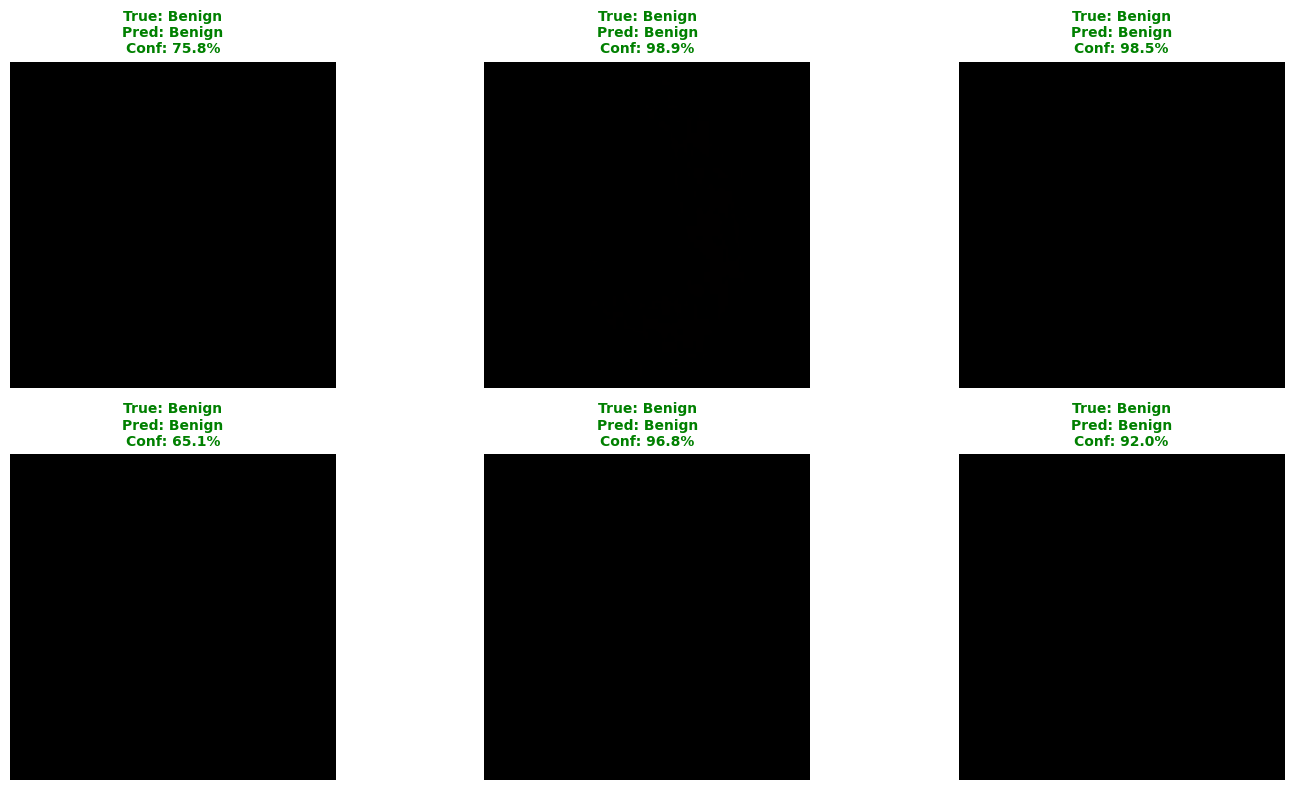


Showing 6 sample predictions from test set


In [20]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model as keras_load_model

print("\n" + "=" * 70)
print("INDIVIDUAL PREDICTION EXAMPLES")
print("=" * 70)

# Load best model for predictions
best_model_path = 'skin_cancer_cnn_best.h5'
if os.path.exists(best_model_path):
    pred_model = keras_load_model(best_model_path)
else:
    pred_model = model

def predict_skin_cancer(image_path, model):
    """Make prediction on a single image"""
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array, verbose=0)
    confidence = float(prediction[0, 0])
    class_label = "Malignant" if confidence > 0.5 else "Benign"
    confidence_score = confidence if confidence > 0.5 else 1 - confidence
    
    return class_label, confidence_score, img, confidence

# Get sample images from test set
print("\nAnalyzing sample predictions from test set...")
sample_count = 0
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for image_batch, label_batch in test_generator:
    if sample_count >= 6:
        break
    
    for img_array, true_label in zip(image_batch, label_batch):
        if sample_count >= 6:
            break
        
        # Get prediction
        img_array_expanded = np.expand_dims(img_array, axis=0)
        prediction = pred_model.predict(img_array_expanded, verbose=0)
        raw_pred = float(prediction[0, 0])
        
        pred_label = "Malignant" if raw_pred > 0.5 else "Benign"
        confidence = raw_pred if raw_pred > 0.5 else 1 - raw_pred
        
        true_class = list(test_generator.class_indices.keys())[int(true_label)]
        is_correct = (pred_label == true_class)
        
        # Plot
        ax = axes[sample_count]
        ax.imshow(img_array.astype('uint8'))
        
        # Title with color coding
        color = 'green' if is_correct else 'red'
        title = f"True: {true_class}\nPred: {pred_label}\nConf: {confidence:.1%}"
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')
        ax.axis('off')
        
        sample_count += 1

plt.tight_layout()
plt.show()

print(f"\nShowing {sample_count} sample predictions from test set")
print("=" * 70)


In [21]:

# Test on new image
predict_skin_cancer("D:\Skin Cancer Detection\img.png", model)

('Benign',
 0.6784938275814056,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>,
 0.32150617241859436)

In [22]:

# Test on new image
predict_skin_cancer("/kaggle/input/melanoma-cancer-dataset/train/Malignant/1004.jpg", model)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/melanoma-cancer-dataset/train/Malignant/1004.jpg'